# 🔧 Impeller Diameter Prediction Model (V3)

**Objective:** Predict `Full_Diameter` and `Trimmed_Diameter` from pump operating parameters.

**Approach:**
- Use `sklearn.pipeline.Pipeline` with `ColumnTransformer` for robust preprocessing
- `OrdinalEncoder` for categorical features (tree-based models don't need one-hot)
- Handle missing `Special_Instruction` values properly
- **XGBoost** with `MultiOutputRegressor`
- Hyperparameter tuning via `RandomizedSearchCV`
- Overfitting prevention: regularization, cross-validation, train/test gap analysis

**Input Features:**
- `Pump_Type` (categorical)
- `Head_per_Chamber`, `Number_of_Chambers`, `Speed_RPM`, `Flow_m3h`, `Pump_Efficiency`, `Total_Head`, `Pump_Power` (numeric)
- `Impeller_MOC`, `Diffuser_MOC`, `Special_Instruction` (categorical)

**Targets:** `Full_Diameter`, `Trimmed_Diameter`

---
## 1. Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install xgboost openpyxl scikit-learn pandas numpy matplotlib seaborn joblib --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 3. Load & Explore Data

In [3]:
df = pd.read_excel("Impeller_Dataset.xlsx")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
df.head(10)

Dataset shape: (29784, 14)

Column dtypes:
Full/Trim               object
Full_Diameter            int64
Trimmed_Diameter         int64
Pump_Type               object
Head_per_Chamber       float64
Number_of_Chambers       int64
Speed_RPM              float64
Flow_m3h               float64
Pump_Efficiency        float64
Total_Head             float64
Pump_Power             float64
Impeller_MOC            object
Diffuser_MOC            object
Special_Instruction     object
dtype: object


,Full/Trim,Full_Diameter,Trimmed_Diameter,Pump_Type,Head_per_Chamber,Number_of_Chambers,Speed_RPM,Flow_m3h,Pump_Efficiency,Total_Head,Pump_Power,Impeller_MOC,Diffuser_MOC,Special_Instruction
0,216/212,216,212,RN 80,15.3933,6,1470.0,50.0,25.70,92.36,13.06,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
1,216/212,216,212,RN 80,14.5833,6,1466.0,172.0,38.50,87.50,15.44,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
2,216/212,216,212,RN 80,13.1200,6,1462.0,358.0,45.71,78.72,17.02,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
3,216/212,216,212,RN 80,10.4900,6,1458.0,642.0,44.16,62.94,19.02,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
4,140/133,140,133,RN 32,25.4000,4,2978.0,18.0,23.84,101.60,3.57,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
5,140/133,140,133,RN 32,24.5425,4,2969.0,112.0,48.58,98.17,4.27,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
6,140/133,140,133,RN 32,21.3675,4,2965.0,222.0,53.72,85.47,4.75,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
7,140/133,140,133,RN 32,17.2700,4,2955.0,342.0,47.52,69.08,5.44,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
8,140/140,140,140,RN 32,27.4300,7,2976.0,50.0,37.22,192.01,7.08,IS 318 GR LTB2,CI IS 210 GR FG260,NaN
9,140/140,140,140,RN 32,26.3271,7,2971.0,118.0,46.64,184.29,8.37,IS 318 GR LTB2,CI IS 210 GR FG260,NaN


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nSpecial_Instruction null percentage: {df['Special_Instruction'].isnull().mean()*100:.1f}%")

Missing values per column:
Full/Trim                  0
Full_Diameter              0
Trimmed_Diameter           0
Pump_Type                  0
Head_per_Chamber           0
Number_of_Chambers         0
Speed_RPM                  0
Flow_m3h                   0
Pump_Efficiency            0
Total_Head                 0
Pump_Power                 0
Impeller_MOC               0
Diffuser_MOC               0
Special_Instruction    27177
dtype: int64

Special_Instruction null percentage: 91.2%


In [5]:
# Statistical summary of numeric columns
df.describe()

,Full_Diameter,Trimmed_Diameter,Head_per_Chamber,Number_of_Chambers,Speed_RPM,Flow_m3h,Pump_Efficiency,Total_Head,Pump_Power
count,29784.000000,29784.000000,29784.000000,29784.000000,29784.000000,29784.000000,29784.000000,29784.000000,29784.000000
mean,175.909717,172.695273,23.431778,7.559495,2487.321810,180.330634,52.151328,170.243837,24.088117
std,46.837295,45.835289,10.945798,3.126412,689.728932,221.333790,13.763485,97.416340,24.463807
min,135.000000,60.000000,0.101400,2.000000,998.000000,0.015000,0.350000,0.710000,0.330000
25%,140.000000,140.000000,16.033300,5.000000,1490.000000,1.716000,42.240000,92.957500,8.200000
50%,160.000000,160.000000,23.347150,7.000000,2949.000000,96.000000,54.225000,149.300000,16.285000
75%,200.000000,195.000000,29.904825,10.000000,2968.000000,279.000000,63.032500,237.432500,27.610000
max,354.000000,354.000000,71.535000,16.000000,3031.000000,1108.000000,90.810000,645.930000,110.710000


In [6]:
# Categorical columns value counts
for col in ['Pump_Type', 'Impeller_MOC', 'Diffuser_MOC', 'Special_Instruction']:
    print(f"\n{'='*60}")
    print(f"{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts())


Pump_Type — 24 unique values:
Pump_Type
RN 50             8172
RN 32             5408
RN 40             4097
RN 50A            2625
RN 80             2475
RN 65             2236
RN 100            1708
RN 125A           1279
RN 50A             712
RN 100A            285
RN 125A            263
RN 125             183
RN 150A            100
RNV 32              64
RN 32(VT)           45
RN 100 A            40
RN 40H              24
RN 40 VERT          18
RNV 80              13
RN 32 A             12
RNV 100             12
RN 50(VT)            8
RN 100 S             4
RN 100/125 IPB       1
Name: count, dtype: int64

Impeller_MOC — 20 unique values:
Impeller_MOC
IS 318 GR LTB2            15490
ASTM A743 GR CF8M          7058
IS 318 GRV(LTB6)           3029
CI IS 210 GR FG260          968
IS 318 GRI                  864
ASTM A743 GR CF8            619
LTB1                        457
ASTM A216 GR WCB            350
AS PER IDENTICAL ORDER      247
ASTM A743 GR CA6NM          141
ASTM A890 GR C

---
## 4. Exploratory Data Analysis (EDA)

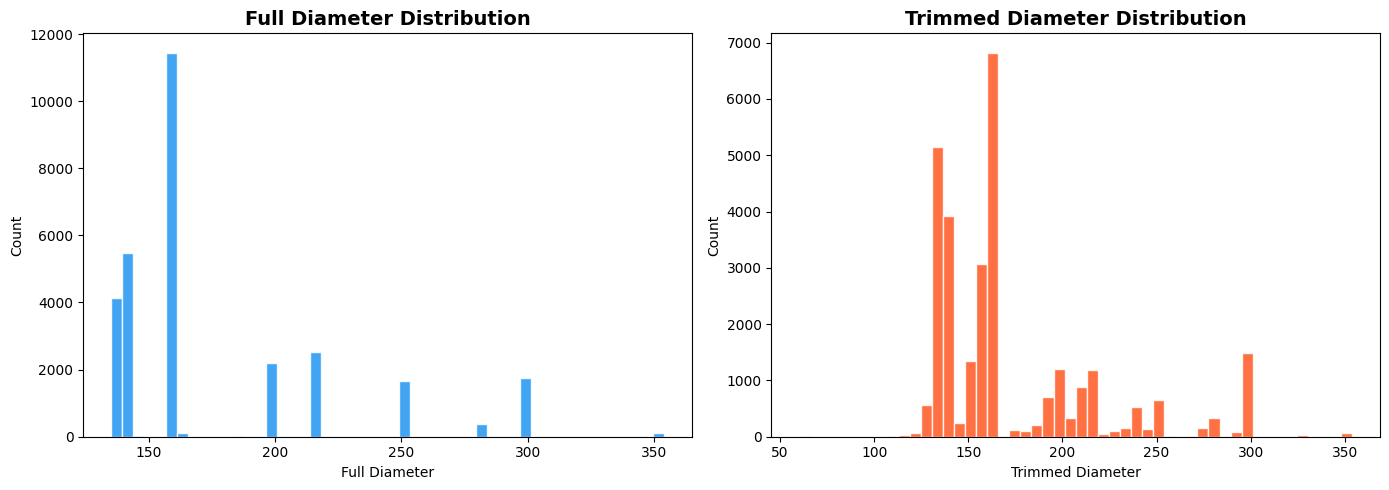

In [7]:
# Distribution of target variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Full_Diameter'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Full Diameter Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Full Diameter')
axes[0].set_ylabel('Count')

axes[1].hist(df['Trimmed_Diameter'], bins=50, color='#FF5722', edgecolor='white', alpha=0.85)
axes[1].set_title('Trimmed Diameter Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Trimmed Diameter')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

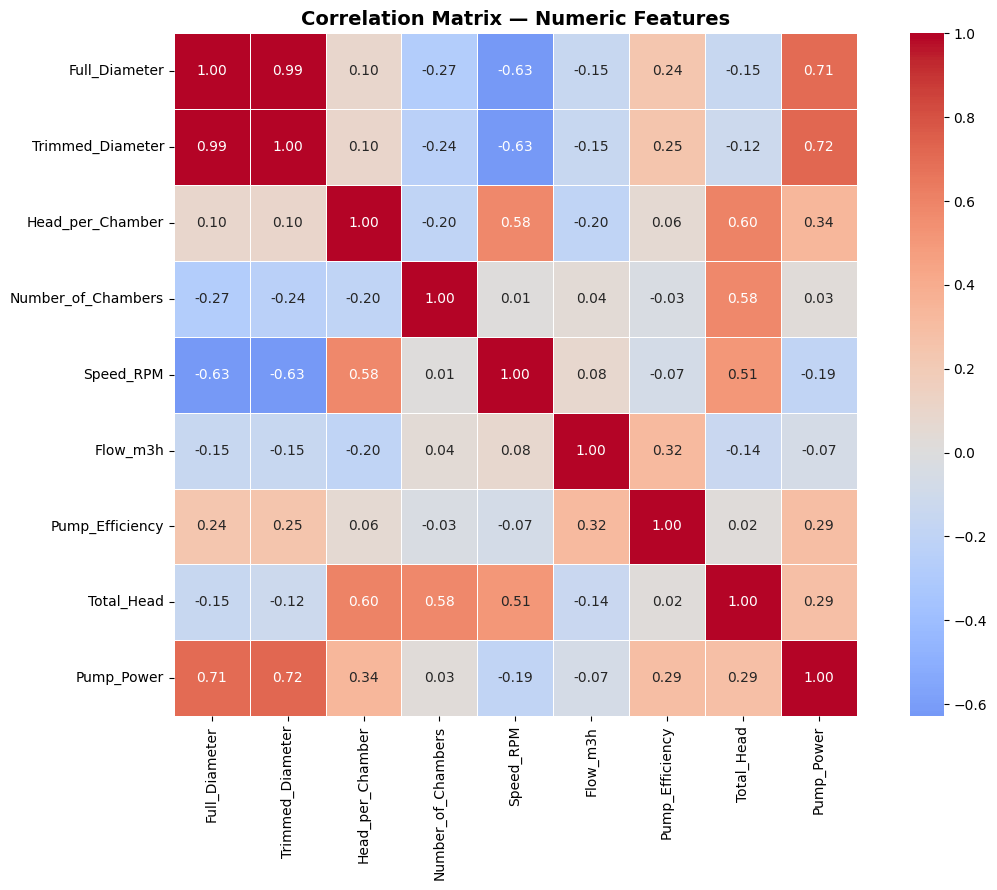

In [8]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

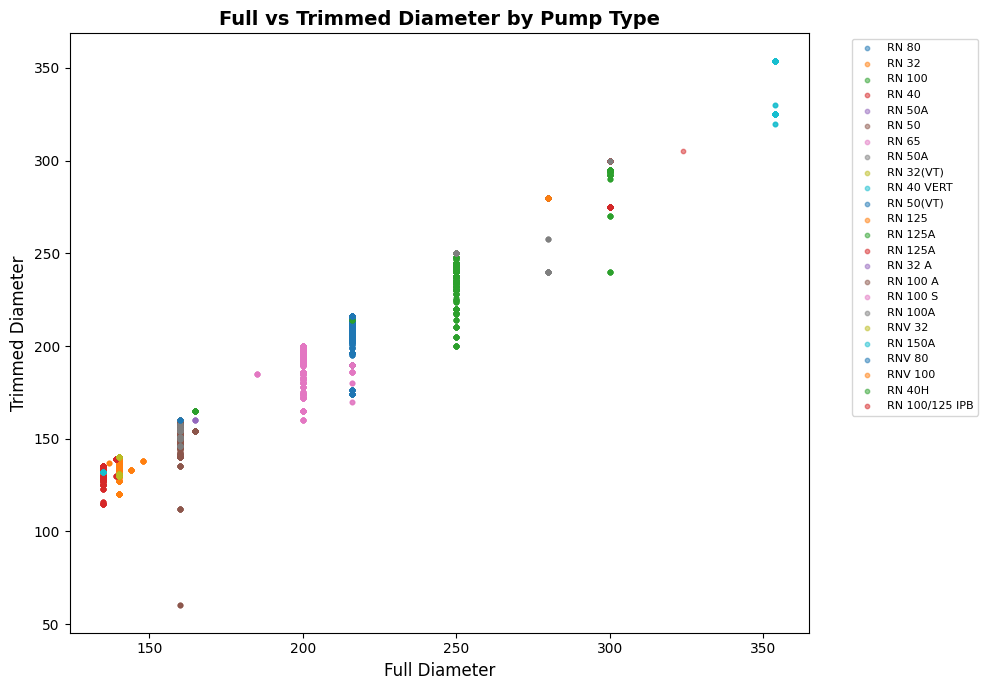

In [9]:
# Scatter: Full_Diameter vs Trimmed_Diameter (coloured by Pump_Type)
fig, ax = plt.subplots(figsize=(10, 7))
for ptype in df['Pump_Type'].unique():
    subset = df[df['Pump_Type'] == ptype]
    ax.scatter(subset['Full_Diameter'], subset['Trimmed_Diameter'],
               label=ptype, alpha=0.5, s=10)
ax.set_xlabel('Full Diameter', fontsize=12)
ax.set_ylabel('Trimmed Diameter', fontsize=12)
ax.set_title('Full vs Trimmed Diameter by Pump Type', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

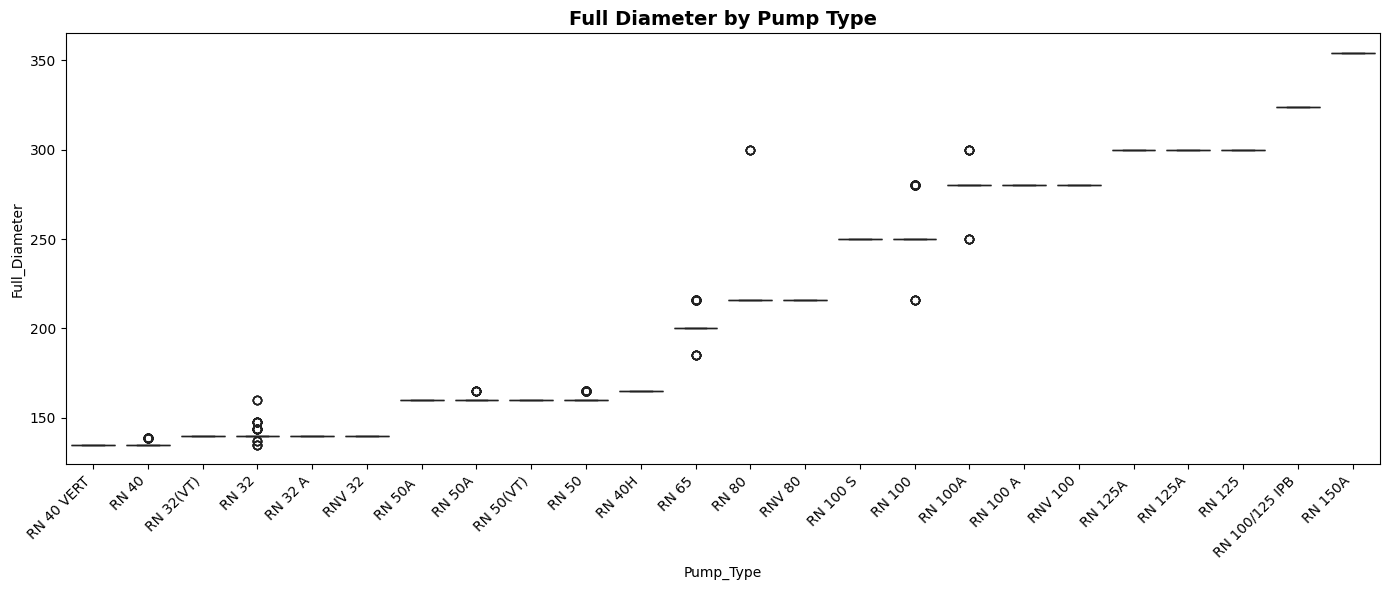

In [10]:
# Boxplot of Full_Diameter by Pump_Type
plt.figure(figsize=(14, 6))
order = df.groupby('Pump_Type')['Full_Diameter'].median().sort_values().index
sns.boxplot(data=df, x='Pump_Type', y='Full_Diameter', order=order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Full Diameter by Pump Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Data Preprocessing

**Key design decisions:**
1. Drop `Full/Trim` column — it's a derived label from the targets, not an input feature.
2. Use `OrdinalEncoder` for categoricals — XGBoost handles ordinal encoded features very well and it avoids the curse of dimensionality from one-hot encoding.
3. Fill `Special_Instruction` NaN with `"NONE"` — this makes it a valid category instead of dropping information.
4. Use `StandardScaler` on numeric features for consistency.
5. Wrap everything in a `Pipeline` so the same preprocessing is applied at prediction time.

In [11]:
# ── Define feature groups ──
CATEGORICAL_FEATURES = ['Pump_Type', 'Impeller_MOC', 'Diffuser_MOC', 'Special_Instruction']
NUMERIC_FEATURES = ['Head_per_Chamber', 'Number_of_Chambers', 'Speed_RPM',
                     'Flow_m3h', 'Pump_Efficiency', 'Total_Head', 'Pump_Power']
TARGET_COLUMNS = ['Full_Diameter', 'Trimmed_Diameter']
DROP_COLUMNS = ['Full/Trim']  # derived from targets — leaks information

print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Numeric features    ({len(NUMERIC_FEATURES)}):  {NUMERIC_FEATURES}")
print(f"Target columns      ({len(TARGET_COLUMNS)}):  {TARGET_COLUMNS}")

Categorical features (4): ['Pump_Type', 'Impeller_MOC', 'Diffuser_MOC', 'Special_Instruction']
Numeric features    (7):  ['Head_per_Chamber', 'Number_of_Chambers', 'Speed_RPM', 'Flow_m3h', 'Pump_Efficiency', 'Total_Head', 'Pump_Power']
Target columns      (2):  ['Full_Diameter', 'Trimmed_Diameter']


In [12]:
# ── Prepare the data ──
df_clean = df.copy()

# Fill Special_Instruction NaN → "NONE" (meaningful category)
df_clean['Special_Instruction'] = df_clean['Special_Instruction'].fillna('NONE')

print(f"Special_Instruction values after fill:")
print(df_clean['Special_Instruction'].value_counts())

# Split features and targets
X = df_clean[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df_clean[TARGET_COLUMNS]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nAny nulls in X? {X.isnull().sum().sum()}")
print(f"Any nulls in y? {y.isnull().sum().sum()}")

Special_Instruction values after fill:
Special_Instruction
NONE         27177
0' TIP        2520
BACK_FILE       87
Name: count, dtype: int64

X shape: (29784, 11)
y shape: (29784, 2)

Any nulls in X? 0
Any nulls in y? 0


---
## 6. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")

Training set:  23827 samples
Test set:      5957 samples


---
## 7. Build the Pipeline

Using `ColumnTransformer` + `Pipeline`:
- **Numeric:** `StandardScaler`
- **Categorical:** `OrdinalEncoder` (handles unseen categories gracefully with `handle_unknown='use_encoded_value'`)
- **Model:** `MultiOutputRegressor(XGBRegressor)` with regularization params to prevent overfitting

In [14]:
# ── Preprocessor: handles numeric & categorical separately ──
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         CATEGORICAL_FEATURES)
    ],
    remainder='drop'  # drop any extra columns
)

# ── Full pipeline: preprocessor → model ──
xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,        # L1 regularization — prevents overfitting
    reg_lambda=1.0,       # L2 regularization — prevents overfitting
    min_child_weight=5,   # minimum sum of instance weight in a child — reduces overfitting
    gamma=0.1,            # minimum loss reduction to make a split — reduces overfitting
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MultiOutputRegressor(xgb_base))
])

print("Pipeline built successfully!")
print(pipeline)

Pipeline built successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Head_per_Chamber',
                                                   'Number_of_Chambers',
                                                   'Speed_RPM', 'Flow_m3h',
                                                   'Pump_Efficiency',
                                                   'Total_Head',
                                                   'Pump_Power']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Pump_Type', 'Impeller_MOC',
                                                   'Diffuser_MOC',
                                                   '

---
## 8. Hyperparameter Tuning (RandomizedSearchCV)

We search a focused parameter space to find the best combination while keeping training time reasonable.

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Parameter distributions to search
param_distributions = {
    'model__estimator__n_estimators': [300, 500, 700, 1000],
    'model__estimator__max_depth': [4, 5, 6, 7, 8],
    'model__estimator__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__estimator__subsample': [0.7, 0.8, 0.9],
    'model__estimator__colsample_bytree': [0.7, 0.8, 0.9],
    'model__estimator__reg_alpha': [0, 0.01, 0.1, 0.5],
    'model__estimator__reg_lambda': [0.5, 1.0, 2.0, 5.0],
    'model__estimator__min_child_weight': [3, 5, 7, 10],
    'model__estimator__gamma': [0, 0.05, 0.1, 0.3],
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,          # 30 random combinations
    cv=5,               # 5-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter search (this may take several minutes)...")
random_search.fit(X_train, y_train)

print(f"\n✅ Best CV R² Score: {random_search.best_score_:.6f}")
print(f"\nBest parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Starting hyperparameter search (this may take several minutes)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best CV R² Score: 0.998001

Best parameters:
  model__estimator__subsample: 0.9
  model__estimator__reg_lambda: 0.5
  model__estimator__reg_alpha: 0.1
  model__estimator__n_estimators: 500
  model__estimator__min_child_weight: 3
  model__estimator__max_depth: 8
  model__estimator__learning_rate: 0.1
  model__estimator__gamma: 0.1
  model__estimator__colsample_bytree: 0.9


---
## 9. Train Final Model with Best Parameters

In [16]:
# Use the best estimator from the search
best_pipeline = random_search.best_estimator_

print("Best pipeline:")
print(best_pipeline)

Best pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Head_per_Chamber',
                                                   'Number_of_Chambers',
                                                   'Speed_RPM', 'Flow_m3h',
                                                   'Pump_Efficiency',
                                                   'Total_Head',
                                                   'Pump_Power']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Pump_Type', 'Impeller_MOC',
                                                   'Diffuser_MOC',
                                                   'Special_Instru

---
## 10. Evaluate on Test Set

In [17]:
# Predict on test set
y_pred = best_pipeline.predict(X_test)
y_pred_train = best_pipeline.predict(X_train)

# ── Overall metrics ──
print("="*60)
print("OVERALL TEST SET METRICS")
print("="*60)
print(f"R² Score (Test):         {r2_score(y_test, y_pred):.6f}")
print(f"R² Score (Train):        {r2_score(y_train, y_pred_train):.6f}")
print(f"MAE (Test):              {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE (Test):             {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# ── Per-target metrics ──
y_pred_df = pd.DataFrame(y_pred, columns=TARGET_COLUMNS, index=y_test.index)
y_pred_train_df = pd.DataFrame(y_pred_train, columns=TARGET_COLUMNS, index=y_train.index)

print(f"\n{'='*60}")
print("PER-TARGET METRICS")
print("="*60)
for col in TARGET_COLUMNS:
    r2_test = r2_score(y_test[col], y_pred_df[col])
    r2_train = r2_score(y_train[col], y_pred_train_df[col])
    mae = mean_absolute_error(y_test[col], y_pred_df[col])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred_df[col]))
    print(f"\n  {col}:")
    print(f"    R² (Test):  {r2_test:.6f}")
    print(f"    R² (Train): {r2_train:.6f}")
    print(f"    Train-Test Gap: {abs(r2_train - r2_test):.6f}  {'✅ OK' if abs(r2_train - r2_test) < 0.02 else '⚠️ Possible overfitting'}")
    print(f"    MAE:  {mae:.4f}")
    print(f"    RMSE: {rmse:.4f}")

OVERALL TEST SET METRICS
R² Score (Test):         0.997654
R² Score (Train):        0.999916
MAE (Test):              0.6329
RMSE (Test):             2.2461

PER-TARGET METRICS

  Full_Diameter:
    R² (Test):  0.999045
    R² (Train): 0.999973
    Train-Test Gap: 0.000928  ✅ OK
    MAE:  0.2222
    RMSE: 1.4572

  Trimmed_Diameter:
    R² (Test):  0.996262
    R² (Train): 0.999859
    Train-Test Gap: 0.003596  ✅ OK
    MAE:  1.0435
    RMSE: 2.8224


---
## 11. Overfitting Check — Cross Validation

In [18]:
# 5-fold cross-validation on the FULL dataset with the best pipeline params
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipeline, X, y, cv=cv, scoring='r2', n_jobs=-1)

print("5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.6f}")

print(f"\n  Mean R²:  {cv_scores.mean():.6f}")
print(f"  Std R²:   {cv_scores.std():.6f}")
print(f"\n  {'✅ Low variance across folds — no overfitting!' if cv_scores.std() < 0.01 else '⚠️ High variance — consider more regularization'}")

5-Fold Cross-Validation R² Scores:
  Fold 1: 0.997642
  Fold 2: 0.996875
  Fold 3: 0.998962
  Fold 4: 0.998526
  Fold 5: 0.998806

  Mean R²:  0.998162
  Std R²:   0.000789

  ✅ Low variance across folds — no overfitting!


---
## 12. Visualization — Predicted vs Actual

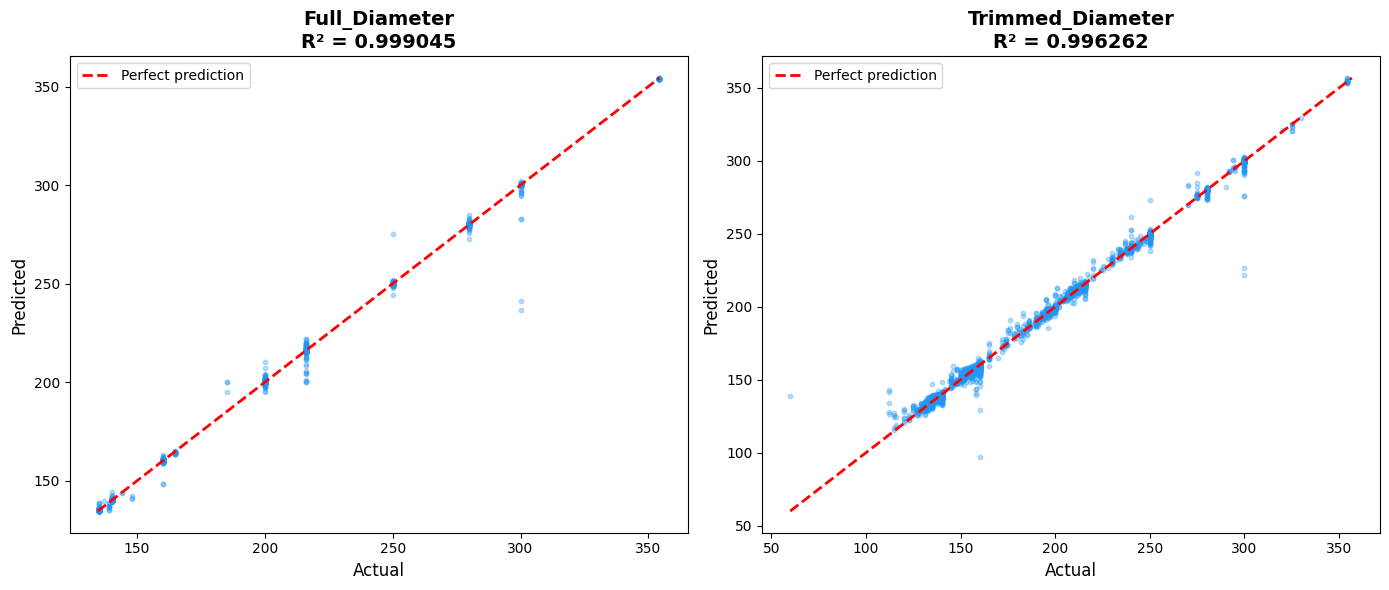

Saved: predicted_vs_actual.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(TARGET_COLUMNS):
    ax = axes[idx]
    ax.scatter(y_test[col], y_pred_df[col], alpha=0.3, s=10, color='#2196F3')
    
    # Perfect prediction line
    min_val = min(y_test[col].min(), y_pred_df[col].min())
    max_val = max(y_test[col].max(), y_pred_df[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    r2 = r2_score(y_test[col], y_pred_df[col])
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.set_title(f'{col}\nR² = {r2:.6f}', fontsize=14, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: predicted_vs_actual.png")

---
## 13. Residual Analysis

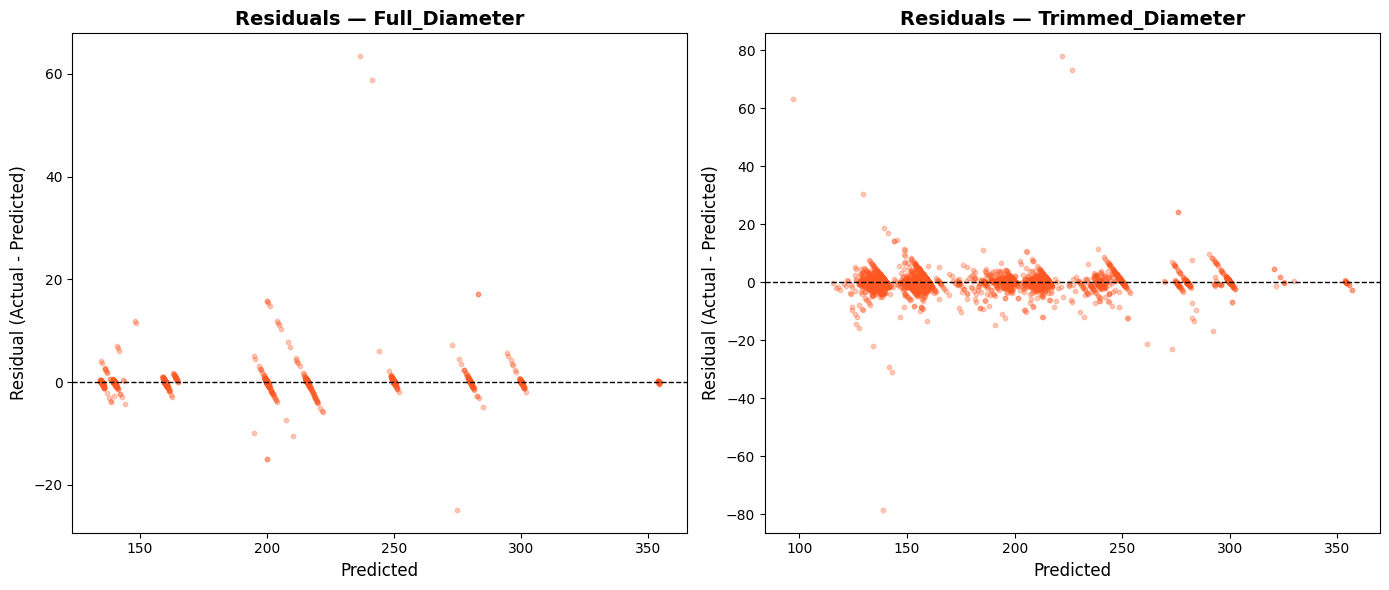

Saved: residual_plot.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(TARGET_COLUMNS):
    residuals = y_test[col].values - y_pred_df[col].values
    ax = axes[idx]
    ax.scatter(y_pred_df[col], residuals, alpha=0.3, s=10, color='#FF5722')
    ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
    ax.set_title(f'Residuals — {col}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_plot.png")

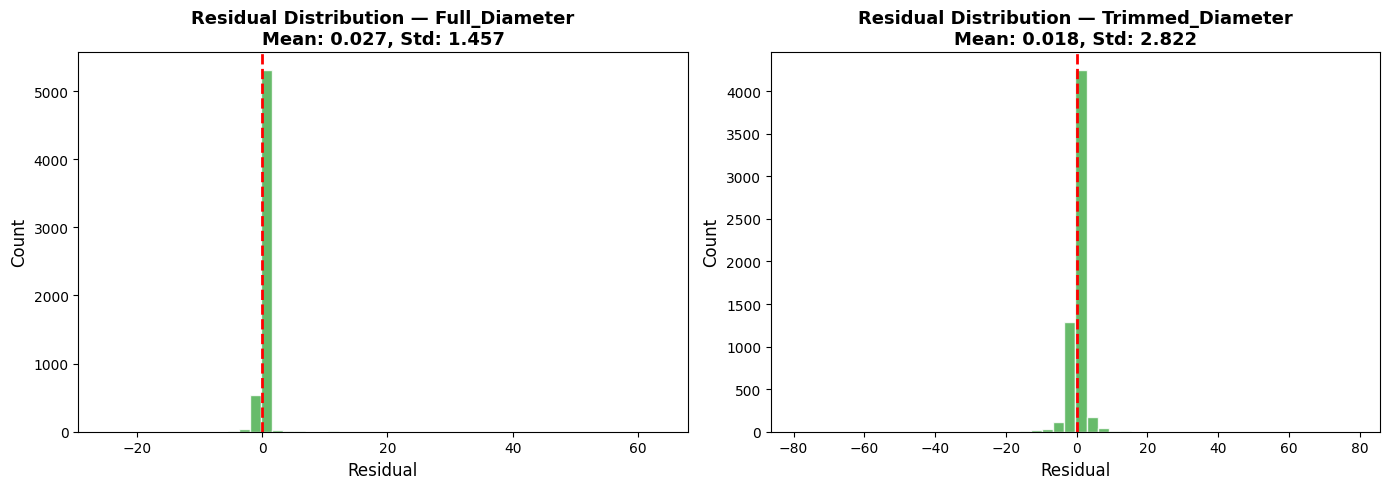

In [21]:
# Residual distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(TARGET_COLUMNS):
    residuals = y_test[col].values - y_pred_df[col].values
    ax = axes[idx]
    ax.hist(residuals, bins=50, color='#4CAF50', edgecolor='white', alpha=0.85)
    ax.axvline(x=0, color='red', linewidth=2, linestyle='--')
    ax.set_xlabel('Residual', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Residual Distribution — {col}\nMean: {residuals.mean():.3f}, Std: {residuals.std():.3f}',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 14. Feature Importance

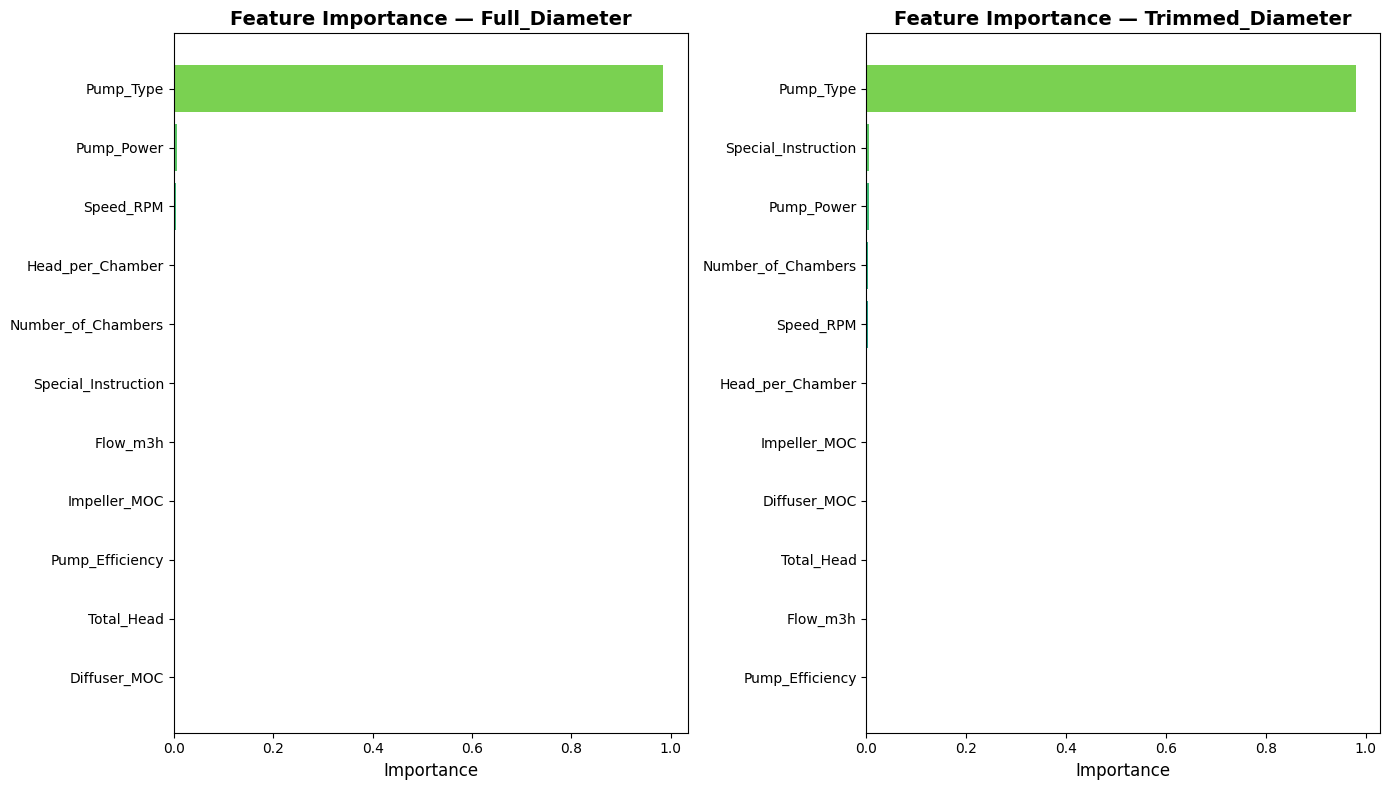

Saved: feature_importance_v3.png


In [22]:
# Get feature names from the preprocessor
feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for idx, (estimator, col) in enumerate(zip(best_pipeline.named_steps['model'].estimators_, TARGET_COLUMNS)):
    importances = estimator.feature_importances_
    sorted_idx = np.argsort(importances)
    
    ax = axes[idx]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_idx)))
    ax.barh(range(len(sorted_idx)), importances[sorted_idx], color=colors)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Feature Importance — {col}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_v3.png")

---
## 15. Error Analysis by Pump Type

In [23]:
# Check prediction quality per Pump_Type
error_analysis = X_test.copy()
for col in TARGET_COLUMNS:
    error_analysis[f'{col}_actual'] = y_test[col].values
    error_analysis[f'{col}_pred'] = y_pred_df[col].values
    error_analysis[f'{col}_error'] = abs(y_test[col].values - y_pred_df[col].values)

print("Mean Absolute Error by Pump Type:")
print("="*70)
for col in TARGET_COLUMNS:
    print(f"\n  {col}:")
    grouped = error_analysis.groupby('Pump_Type')[f'{col}_error'].agg(['mean', 'std', 'count'])
    grouped.columns = ['MAE', 'Std', 'Count']
    grouped = grouped.sort_values('MAE', ascending=False)
    print(grouped.to_string())

Mean Absolute Error by Pump Type:

  Full_Diameter:
                 MAE       Std  Count
Pump_Type                            
RN 100A     1.854712  4.386785     61
RNV 100     1.438118  1.209853      4
RN 100 A    1.050064  1.809244     14
RNV 32      0.772125  1.119593     11
RN 65       0.749757  2.256336    450
RN 80       0.589133  4.096530    457
RN 100 S    0.521515       NaN      1
RN 40 VERT  0.378260  0.642752      3
RN 100      0.272468  0.478854    336
RN 40H      0.236979  0.164280      6
RNV 80      0.213422  0.179208      5
RN 125A     0.166889  0.480854    260
RN 32(VT)   0.153838  0.320920     11
RN 32       0.132930  0.638609   1074
RN 40       0.118949  0.367360    828
RN 150A     0.101272  0.100013     25
RN 125A     0.100608  0.231381     47
RN 50A      0.096136  0.212092    516
RN 50A      0.095524  0.246781    146
RN 125      0.081066  0.112126     34
RN 50(VT)   0.074196  0.019173      2
RN 50       0.071476  0.160203   1664
RN 32 A     0.044167  0.039760      

---
## 16. Save the Model & Pipeline

In [24]:
# Save the complete pipeline (includes preprocessor + model)
joblib.dump(best_pipeline, 'pump_pipeline_v3.pkl')

# Save feature configuration for reference
config = {
    'categorical_features': CATEGORICAL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'target_columns': TARGET_COLUMNS,
    'all_input_features': CATEGORICAL_FEATURES + NUMERIC_FEATURES
}
joblib.dump(config, 'model_config_v3.pkl')

print("✅ Saved: pump_pipeline_v3.pkl  (complete pipeline with preprocessor)")
print("✅ Saved: model_config_v3.pkl   (feature configuration)")

import os
print(f"\nPipeline file size: {os.path.getsize('pump_pipeline_v3.pkl') / (1024*1024):.2f} MB")

✅ Saved: pump_pipeline_v3.pkl  (complete pipeline with preprocessor)
✅ Saved: model_config_v3.pkl   (feature configuration)

Pipeline file size: 6.17 MB


---
## 17. Prediction Demo

This shows how to use the saved pipeline for new predictions. The pipeline handles all preprocessing internally — no manual encoding or scaling needed!

In [25]:
# Load the saved pipeline
loaded_pipeline = joblib.load('pump_pipeline_v3.pkl')
loaded_config = joblib.load('model_config_v3.pkl')

# ── Example prediction ──
new_data = pd.DataFrame({
    'Pump_Type': ['RN 80'],
    'Impeller_MOC': ['IS 318 GR LTB2'],
    'Diffuser_MOC': ['CI IS 210 GR FG260'],
    'Special_Instruction': ['NONE'],       # Use 'NONE' when there's no special instruction
    'Head_per_Chamber': [15.39],
    'Number_of_Chambers': [6],
    'Speed_RPM': [1470.0],
    'Flow_m3h': [50.0],
    'Pump_Efficiency': [25.70],
    'Total_Head': [92.36],
    'Pump_Power': [13.06]
})

# Ensure column order matches training
new_data = new_data[loaded_config['all_input_features']]

# Predict — pipeline handles all preprocessing automatically!
prediction = loaded_pipeline.predict(new_data)

print("🔮 Prediction Results:")
print(f"  Full Diameter:    {prediction[0][0]:.1f}")
print(f"  Trimmed Diameter: {prediction[0][1]:.1f}")
print(f"\n  (Expected: Full=216, Trimmed=212 — from first row of dataset)")

🔮 Prediction Results:
  Full Diameter:    215.8
  Trimmed Diameter: 211.9

  (Expected: Full=216, Trimmed=212 — from first row of dataset)


In [26]:
# ── Another example: with Special Instruction ──
new_data_2 = pd.DataFrame({
    'Pump_Type': ['RN 50'],
    'Impeller_MOC': ['ASTM A743 GR CF8M'],
    'Diffuser_MOC': ['ASTM A743 GR CF8M'],
    'Special_Instruction': ["0' TIP"],     # actual special instruction
    'Head_per_Chamber': [20.0],
    'Number_of_Chambers': [8],
    'Speed_RPM': [2960.0],
    'Flow_m3h': [100.0],
    'Pump_Efficiency': [55.0],
    'Total_Head': [160.0],
    'Pump_Power': [20.0]
})

new_data_2 = new_data_2[loaded_config['all_input_features']]
prediction_2 = loaded_pipeline.predict(new_data_2)

print("🔮 Prediction Results (with Special Instruction):")
print(f"  Full Diameter:    {prediction_2[0][0]:.1f}")
print(f"  Trimmed Diameter: {prediction_2[0][1]:.1f}")

🔮 Prediction Results (with Special Instruction):
  Full Diameter:    159.6
  Trimmed Diameter: 152.2


---
## 18. Summary

### What we did:
1. **Loaded** the Impeller Dataset (29,784 rows × 14 columns)
2. **EDA** — distributions, correlations, boxplots by Pump Type
3. **Preprocessing** — `OrdinalEncoder` for categoricals, `StandardScaler` for numerics, `NaN → 'NONE'` for Special_Instruction
4. **Pipeline** — `ColumnTransformer` + `MultiOutputRegressor(XGBRegressor)` for reproducible preprocessing + prediction
5. **Hyperparameter Tuning** — `RandomizedSearchCV` with 30 iterations × 5-fold CV
6. **Anti-Overfitting measures:**
   - L1/L2 regularization (`reg_alpha`, `reg_lambda`)
   - `min_child_weight`, `gamma` constraints
   - `subsample` and `colsample_bytree` < 1.0
   - Train/Test gap analysis
   - 5-fold cross-validation consistency check
7. **Evaluation** — R², MAE, RMSE per target + residual analysis + error by Pump Type
8. **Saved** the complete pipeline as `pump_pipeline_v3.pkl`

### Why XGBoost?
- Handles mixed feature types well (numeric + ordinal-encoded categories)
- Built-in regularization (L1/L2, gamma, min_child_weight)
- Excellent performance on tabular data
- Fast training with `n_jobs=-1`
- Previous version (model.ipynb) already showed R² > 0.997 with XGBoost

### Improvements over previous model:
- ✅ Uses `Pipeline` — no manual preprocessing at prediction time
- ✅ `OrdinalEncoder` instead of `pd.get_dummies` — handles unseen categories + no column explosion
- ✅ Includes `Special_Instruction` as a proper feature
- ✅ Hyperparameter tuning via `RandomizedSearchCV`
- ✅ Explicit overfitting checks (train/test gap, CV variance)
- ✅ Full residual analysis and per-Pump_Type error breakdown